# Inicjalizacja | Feature Engineering | Random Forest

In [1]:
import pandas as pd
import numpy as np
import glob
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import joblib 
import os

print("="*80)
print(">>> KROK 1: INICJALIZACJA, INŻYNIERIA CECH I TRENING RF <<<")
print("="*80)

# ==========================================
# 1. WCZYTANIE DANYCH 
# ==========================================
df_train_raw = pd.read_csv('../dane/gotowe_ml/honeypot_ml_ready.csv', low_memory=False)

classes_to_drop = ['Background Noise', 'Rare / Minor Anomalies']
df_train_raw = df_train_raw[~df_train_raw['Refined_Label'].isin(classes_to_drop)].copy()

# Opcjonalne: ładowanie plików testowych (prawdziwa weryfikacja odbędzie się w Notatniku 05)
test_files = glob.glob('../dane/testowe/*.csv')
dfs_test = [pd.read_csv(f, on_bad_lines="skip", low_memory=False) for f in test_files]
df_test_raw = pd.concat(dfs_test, ignore_index=True) if dfs_test else pd.DataFrame()

print(f"[*] Wczytano Złoty Standard (Tylko czyste kampanie!): {len(df_train_raw)} rekordów.")
if not df_test_raw.empty:
    print(f"[*] Wczytano Surowe Logi (Przyszłość): {len(df_test_raw)} rekordów (do wglądu).")

# ==========================================
# 1.5 PODZIAŁ LOSOWY ZE STRATYFIKACJĄ (ŚWIAT ZAMKNIĘTY - BASELINE)
# ==========================================
from sklearn.model_selection import train_test_split

print("[*] Wykonywanie klasycznego podziału losowego (Closed-World Baseline)...")
df_train, df_val = train_test_split(
    df_train_raw, 
    test_size=0.2, 
    stratify=df_train_raw['Refined_Label'], 
    random_state=42
)

print(f"[*] Podział ze stratyfikacją (Zachowanie proporcji klas):")
print(f"    - Trening wewnętrzny: {len(df_train)} próbek")
print(f"    - Walidacja wewnętrzna: {len(df_val)} próbek")

# ==========================================
# 2. DEFINICJA CECH I BEZPIECZNE SŁOWNIKI (BEZ WYCIEKU KODOWANIA)
# ==========================================
FEATURES = [
    'Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 
    'Bytes_per_Pkt', 'Pkts_Freq', 'Pkts_Ratio', 'Bytes_Ratio', 
    'is_well_known_port', 'is_ephemeral_port',
    'Proto_Enc', 'State_Enc', 'Dport_Num'
]

# Słowniki budujemy TYLKO na zbiorze uczącym (df_train), by model nie widział przyszłości!
known_protos = {p: i for i, p in enumerate(df_train['Proto'].astype(str).unique())}
known_states = {s: i for i, s in enumerate(df_train['State'].astype(str).unique())}

if not os.path.exists('../modele'): os.makedirs('../modele')
joblib.dump(known_protos, '../modele/known_protos.joblib')
joblib.dump(known_states, '../modele/known_states.joblib')
print("[+] Zamrożono słowniki kategorii (gotowe do środowiska produkcyjnego).")

def safe_encode(val, mapping_dict): return mapping_dict.get(str(val), -1)
def safe_port(p):
    try: return int(str(p), 16) if str(p).startswith('0x') else int(float(p))
    except: return 0

# ==========================================
# 3. PRZYGOTOWANIE ZBIORÓW DO TRENINGU 
# ==========================================
print("\n[*] Formowanie Złotego Standardu...")

# Mapowanie dla Treningu i Walidacji
for df in [df_train, df_val]:
    df['Proto_Enc'] = df['Proto'].apply(lambda x: safe_encode(x, known_protos))
    df['State_Enc'] = df['State'].apply(lambda x: safe_encode(x, known_states))
    df['Dport_Num'] = df['Dport'].apply(safe_port)

X_train = df_train[FEATURES].fillna(0)
y_train = df_train['Refined_Label']

X_val = df_val[FEATURES].fillna(0)
y_val = df_val['Refined_Label']
# ==========================================
# 4. FUNKCJA DLA SUROWYCH DANYCH Z PRZYSZŁOŚCI 
# ==========================================
def prepare_future_logs(df_input):
    df = df_input.copy()
    for col in ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 'SrcBytes', 'DstBytes']:
        df[col] = pd.to_numeric(df.get(col, 0), errors='coerce').fillna(0)
        
    df['Bytes_per_Pkt'] = df['TotBytes'] / (df['TotPkts'] + 1e-6)
    df['Pkts_Freq']     = df['TotPkts'] / (df['Dur'] + 1e-6)
    df['Pkts_Ratio']    = df['SrcPkts'] / (df['DstPkts'] + 1e-6)
    
    if 'SrcBytes' in df.columns and 'DstBytes' in df.columns:
        df['Bytes_Ratio'] = df['SrcBytes'] / (df['DstBytes'] + 1e-6)
    else: df['Bytes_Ratio'] = 0

    df['Dport_Num'] = df.get('Dport', 0).apply(safe_port)
    df['is_well_known_port'] = ((df['Dport_Num'] > 0) & (df['Dport_Num'] <= 1024)).astype(int)
    df['is_ephemeral_port'] = (df['Dport_Num'] >= 49152).astype(int)

    cols_to_log = ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 
                   'Bytes_per_Pkt', 'Pkts_Freq', 'Pkts_Ratio', 'Bytes_Ratio']
    for col in cols_to_log:
        df[col] = np.log1p(df[col].clip(lower=0))

    df['Proto_Enc'] = df.get('Proto', '').astype(str).apply(lambda x: safe_encode(x, known_protos))
    df['State_Enc'] = df.get('State', '').astype(str).apply(lambda x: safe_encode(x, known_states))
    
    for f in FEATURES:
        if f not in df.columns: df[f] = 0
            
    return df[FEATURES].fillna(0)

# 5. TRENING MODELU WALIDACYJNEGO
print(f"\n[*] Trenowanie modelu walidacyjnego (Drzewa: 300, Stratyfikacja aktywowana)...")
clf_val = RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample', max_features='sqrt', random_state=42, n_jobs=-1)
clf_val.fit(X_train, y_train)

y_pred_val = clf_val.predict(X_val)
acc = (y_pred_val == y_val).mean()
print(f"[+] Model uzbrojony! Precyzja walidacyjna na końcówce okresu: {acc*100:.2f}%\n")

>>> KROK 1: INICJALIZACJA, INŻYNIERIA CECH I TRENING RF <<<
[*] Wczytano Złoty Standard (Tylko czyste kampanie!): 115376 rekordów.
[*] Wykonywanie klasycznego podziału losowego (Closed-World Baseline)...
[*] Podział ze stratyfikacją (Zachowanie proporcji klas):
    - Trening wewnętrzny: 92300 próbek
    - Walidacja wewnętrzna: 23076 próbek
[+] Zamrożono słowniki kategorii (gotowe do środowiska produkcyjnego).

[*] Formowanie Złotego Standardu...

[*] Trenowanie modelu walidacyjnego (Drzewa: 300, Stratyfikacja aktywowana)...
[+] Model uzbrojony! Precyzja walidacyjna na końcówce okresu: 99.96%



In [2]:
# Sprawdzenie, jakie protokoły model znał z treningu
print("[*] Protokoły znane (Trening):", list(known_protos.keys()))

# Sprawdzenie protokołów w masowej kampanii L3 z walidacji
l3_val_protocols = df_val[df_val['Refined_Label'] == 'Non-TCP/UDP Protocol Scan (L3)']['Proto'].unique()
print("[*] Protokoły w kampanii L3 (Walidacja):", l3_val_protocols)

# Sprawdzenie, czy któryś z nich został zakodowany jako -1
for p in l3_val_protocols:
    code = safe_encode(p, known_protos)
    if code == -1:
        print(f"!!! WYKRYTO: Protokół '{p}' jest nieznany dla modelu i otrzymał kod -1.")

[*] Protokoły znane (Trening): ['tcp', 'OTHER', 'icmp', 'udp', '0x0008', '54188', '65529', '8080', 'arp', '65530', '51562']
[*] Protokoły w kampanii L3 (Walidacja): ['0x0008' 'OTHER' '51562' '65529' '8080' '65530' '54188' 'arp' 'udp']


# Ewaluacja | Trening Produkcyjny | Zapis

>>> KROK 2: EWALUACJA WEWNĘTRZNA NA OKRESIE WALIDACYJNYM <<<
[*] Generowanie raportu klasyfikacji...

                        RAPORT KLASYFIKACJI - VALIDATION                        
                                    precision    recall  f1-score   support

            BitTorrent Enumeration     1.0000    1.0000    1.0000         9
                  CoAP Enumeration     1.0000    0.8182    0.9000        11
                   DNS Enumeration     1.0000    1.0000    1.0000        42
                  HTTP Brute Force     1.0000    1.0000    1.0000         9
       HTTP Cross-Protocol Anomaly     1.0000    1.0000    1.0000        12
        HTTP_Alt_Admin Brute Force     1.0000    1.0000    1.0000        73
               High-Port UDP Probe     0.9403    0.9545    0.9474        66
ICMP Fingerprinting (OS Detection)     1.0000    1.0000    1.0000      1087
            ISAKMP_VPN Brute Force     1.0000    1.0000    1.0000        88
                  LDAP Enumeration     1.0000    1.0000 

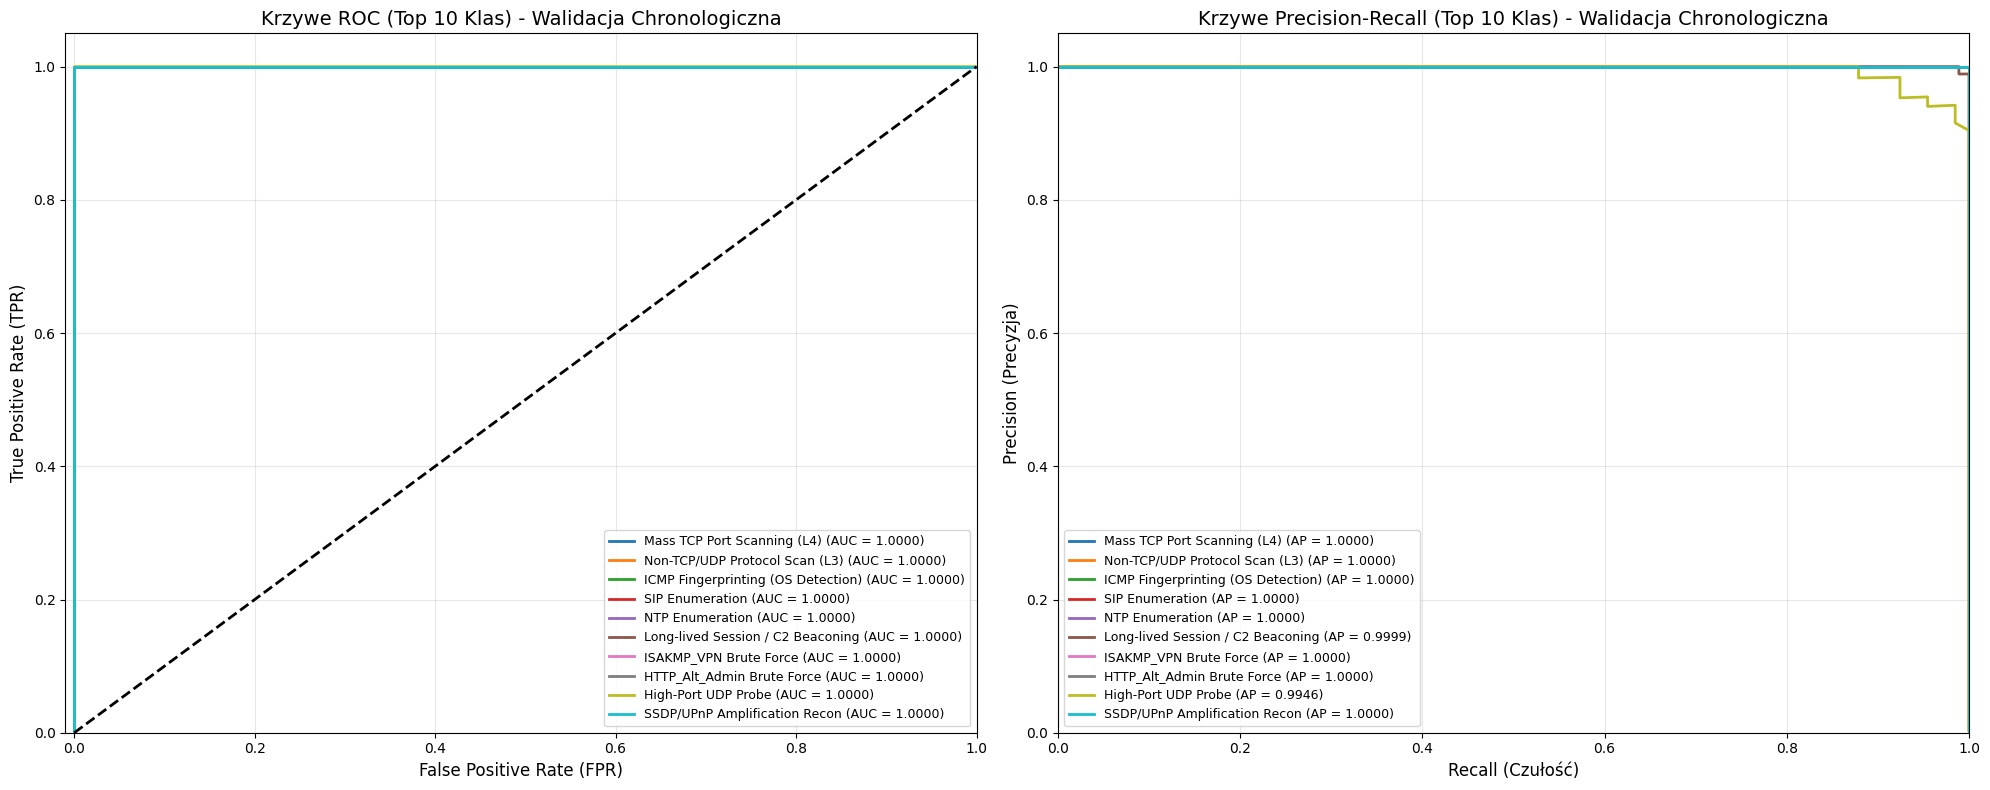


>>> KROK 3: TRENING MODELU PRODUKCYJNEGO I ZAPIS NA DYSK <<<
[*] Formowanie wektorów dla całych 14 dni...
[*] Konsolidacja danych: Trenowanie ostatecznego modelu na całych 14 dniach..
[+] SUKCES! Model produkcyjny wygenerowany i zabezpieczony w: ../modele\rf_production_model.joblib
[+] Model jest gotowy do wdrożenia na arenie Zero-Day (Notatnik 05)!


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, classification_report
from sklearn.preprocessing import label_binarize
import os
import numpy as np
import joblib
import warnings
from sklearn.exceptions import UndefinedMetricWarning

# Wyciszenie ostrzeżeń o braku rzadkich klas w zbiorze testowym (efekt Temporal Split)
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
warnings.filterwarnings('ignore', message='No positive class found in y_true')
warnings.filterwarnings('ignore', message='No positive samples in y_true')

print("="*80)
print(">>> KROK 2: EWALUACJA WEWNĘTRZNA NA OKRESIE WALIDACYJNYM <<<")
print("="*80)

output_dir = '../wykresy'
if not os.path.exists(output_dir): os.makedirs(output_dir)

# 1. RAPORT KLASYFIKACJI (TABELA F1-SCORE)
print("[*] Generowanie raportu klasyfikacji...")
y_pred = clf_val.predict(X_val) # Używamy modelu walidacyjnego

print("\n" + "="*80)
print(f"{'RAPORT KLASYFIKACJI - VALIDATION':^80}")
print("="*80)
print(classification_report(y_val, y_pred, digits=4))
print("="*80 + "\n")

# 2. PRZYGOTOWANIE DO WYKRESÓW
classes = clf_val.classes_
y_val_bin = label_binarize(y_val, classes=classes)
n_classes = y_val_bin.shape[1]

print("[*] Generowanie krzywych ROC i PR dla zbioru walidacyjnego...")
y_score = clf_val.predict_proba(X_val)

fpr, tpr, roc_auc = dict(), dict(), dict()
precision, recall, average_precision = dict(), dict(), dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_val_bin[:, i], y_score[:, i])
    average_precision[i] = average_precision_score(y_val_bin[:, i], y_score[:, i])

top_classes_names = y_val.value_counts().head(10).index
top_classes_idx = [np.where(classes == name)[0][0] for name in top_classes_names]
colors = sns.color_palette("tab10", len(top_classes_idx))

# 3. RYSOWANIE WYKRESÓW
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

for idx, color in zip(top_classes_idx, colors):
    class_name = classes[idx]
    ax1.plot(fpr[idx], tpr[idx], color=color, lw=2, label=f'{class_name} (AUC = {roc_auc[idx]:.4f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=2)
ax1.set_xlim([-0.01, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax1.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax1.set_title('Krzywe ROC (Top 10 Klas) - Walidacja Chronologiczna', fontsize=14)
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(alpha=0.3)

for idx, color in zip(top_classes_idx, colors):
    class_name = classes[idx]
    ax2.plot(recall[idx], precision[idx], color=color, lw=2, label=f'{class_name} (AP = {average_precision[idx]:.4f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Czułość)', fontsize=12)
ax2.set_ylabel('Precision (Precyzja)', fontsize=12)
ax2.set_title('Krzywe Precision-Recall (Top 10 Klas) - Walidacja Chronologiczna', fontsize=14)
ax2.legend(loc="lower left", fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
file_path = os.path.join(output_dir, '9_rf_roc_pr_curves.png')
plt.savefig(file_path, dpi=300)
print(f"[+] Zapisano wykresy ewaluacyjne w: {file_path}")
plt.show()

# ==========================================
# 4. TRENING PRODUKCYJNY (FULL DATASET) I EXPORT
# ==========================================
print("\n" + "="*80)
print(">>> KROK 3: TRENING MODELU PRODUKCYJNEGO I ZAPIS NA DYSK <<<")
print("="*80)

# ---> TEGO BRAKOWAŁO: Przygotowanie całego zbioru (Train + Val) do ostatecznego modelu
print("[*] Formowanie wektorów dla całych 14 dni...")
df_train_raw['Proto_Enc'] = df_train_raw['Proto'].apply(lambda x: safe_encode(x, known_protos))
df_train_raw['State_Enc'] = df_train_raw['State'].apply(lambda x: safe_encode(x, known_states))
df_train_raw['Dport_Num'] = df_train_raw['Dport'].apply(safe_port)

X_train_full = df_train_raw[FEATURES].fillna(0)
y_train_full = df_train_raw['Refined_Label']
# <--- KONIEC DODATKU

print("[*] Konsolidacja danych: Trenowanie ostatecznego modelu na całych 14 dniach..")

clf_prod = RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample', max_features='sqrt', random_state=42, n_jobs=-1)
clf_prod.fit(X_train_full, y_train_full)

model_dir = '../modele'
if not os.path.exists(model_dir): 
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'rf_production_model.joblib')
joblib.dump(clf_prod, model_path)

print(f"[+] SUKCES! Model produkcyjny wygenerowany i zabezpieczony w: {model_path}")
print("[+] Model jest gotowy do wdrożenia na arenie Zero-Day (Notatnik 05)!")